In [10]:
# --- Path setup ---
import sys
import os
import pickle
import warnings
from pathlib import Path

_root = Path.cwd()
while _root != _root.parent and not (_root / "max_k_cut").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

# --- Scientific / data ---
import networkx as nx
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
plt.rcParams.update(
    {
        "figure.dpi": 200,
        "savefig.dpi": 600,
        "font.size": 11,
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "legend.fontsize": 10,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "text.usetex": False,
        "mathtext.fontset": "cm",
    }
)

# --- Qiskit ecosystem ---
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from qiskit_optimization.translators import from_docplex_mp

# --- Project ---
from max_k_cut import (
    docplex_QUBO, docplex_RQUBO, docplex_QUBO_no_constraints,
    tight_qubo_penalty, naive_qubo_penalty,
    tight_rqubo_penalty, naive_rqubo_penalty,
    create_dicke_initial_state, create_ring_xy_mixer,
    plot_graph,
    feasibility_mask_from_qp,
)

warnings.filterwarnings("ignore", category=DeprecationWarning)

DATA_DIR = "Data"
os.makedirs(DATA_DIR, exist_ok=True)
LANDSCAPE_CACHE = os.path.join(DATA_DIR, "cost_landscape_cache.pkl")
print("Data directory:", os.path.abspath(DATA_DIR))
print("Landscape cache:", os.path.abspath(LANDSCAPE_CACHE))

Data directory: /Users/hark469/Projects/max-k-cut/Max_K_Cut/notebooks/experiments/Data
Landscape cache: /Users/hark469/Projects/max-k-cut/Max_K_Cut/notebooks/experiments/Data/cost_landscape_cache.pkl


In [11]:
# ── Configuration ──
K = 3                          # number of partitions
GRID_RES = 1000                 # resolution per axis (100 × 100 grid)
GAMMA_RANGE = (0, 2 * np.pi)  # phase-separation parameter range
BETA_RANGE  = (0, np.pi)      # mixer parameter range

CONTOUR_LEVELS = 150            # number of contour levels in filled plots
CMAP = "RdYlBu_r"             # diverging colormap: red (high) to blue (low)

# CVaR landscapes: alpha = probability mass on best outcomes (max objective); 1 => expectation
CVAR_ALPHA = 0.25
FORCE_RECOMPUTE_CVAR = False  # set True to ignore CVaR cache

Graph: 4 nodes, 6 edges
QUBO qubits: 12,  RQUBO qubits: 8


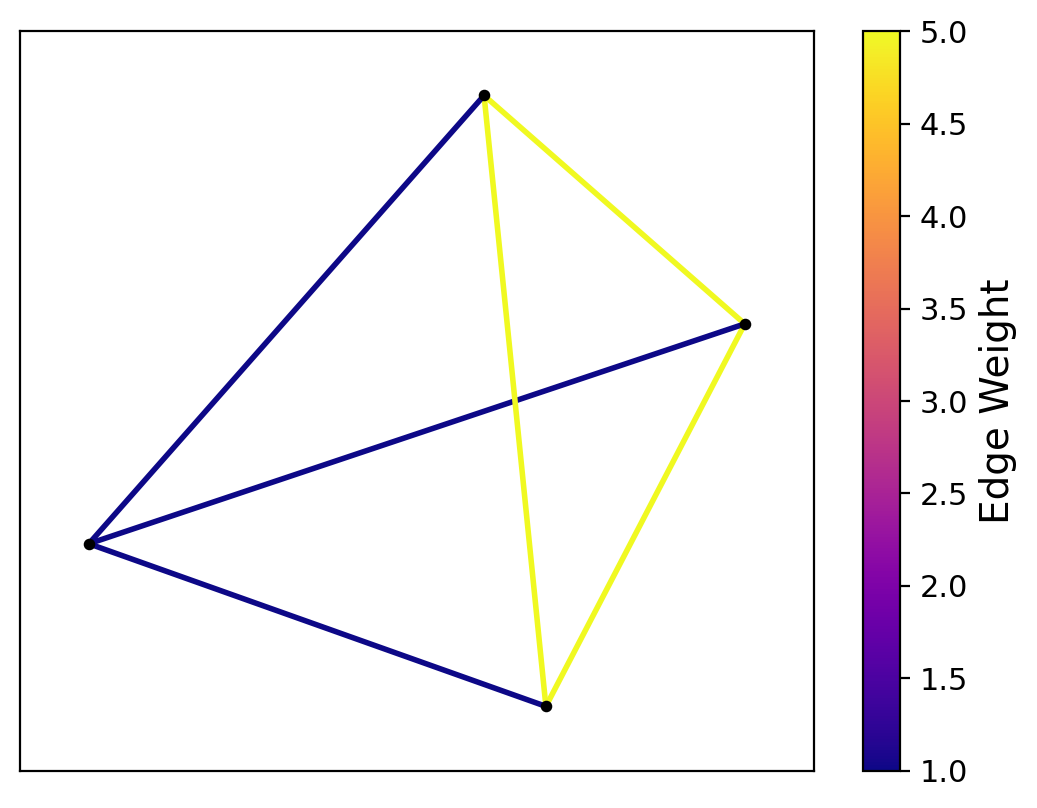

In [12]:
# ── Graph construction ──
# 4-node weighted graph: outer triangle (weight M) + spokes to u~ (weight alpha)
M, alpha = 5, 1
G = nx.Graph()
G.add_edge(0, 1, weight=M)       # u1-u2
G.add_edge(1, 2, weight=M)       # u2-u3
G.add_edge(2, 0, weight=M)       # u3-u1
G.add_edge(0, 3, weight=alpha)   # u1-u~
G.add_edge(1, 3, weight=alpha)   # u2-u~
G.add_edge(2, 3, weight=alpha)   # u3-u~
num_nodes = G.number_of_nodes()

print(f"Graph: {num_nodes} nodes, {G.number_of_edges()} edges")
print(f"QUBO qubits: {num_nodes * K},  RQUBO qubits: {num_nodes * (K - 1)}")
plot_graph(G)

In [13]:
# ── Build Docplex models and convert to Ising Hamiltonians ──

penalty_tight_qubo  = tight_qubo_penalty(G, K)
penalty_naive_qubo  = naive_qubo_penalty(G, K)
penalty_tight_rqubo = tight_rqubo_penalty(G, K)
penalty_naive_rqubo = naive_rqubo_penalty(G, K)

dp_models = {
    "QUBO tight":  docplex_QUBO(G, K, penalty_tight_qubo,  "QUBO_tight"),
    "QUBO naive":  docplex_QUBO(G, K, penalty_naive_qubo,  "QUBO_naive"),
    "QUBO (XY)":   docplex_QUBO_no_constraints(G, K, "QUBO_xy"),
    "RQUBO tight": docplex_RQUBO(G, K, penalty_tight_rqubo, "RQUBO_tight"),
    "RQUBO naive": docplex_RQUBO(G, K, penalty_naive_rqubo, "RQUBO_naive"),
}

ising = {}
for label, dp in dp_models.items():
    qp = from_docplex_mp(dp)
    op, offset = qp.to_ising()
    classical_opt = dp.solve().objective_value
    ising[label] = {"operator": op, "offset": offset, "classical_opt": classical_opt}
    print(f"{label:16s}  qubits={op.num_qubits:2d}  "
          f"offset={offset:+.4f}  classical_opt={classical_opt:.4f}")

print(f"\nPenalty vectors (QUBO):  tight={penalty_tight_qubo},  naive={penalty_naive_qubo}")
print(f"Penalty vectors (RQUBO): tight={penalty_tight_rqubo},  naive={penalty_naive_rqubo}")

QUBO tight        qubits=12  offset=+7.5000  classical_opt=17.0000
QUBO naive        qubits=12  offset=+67.5000  classical_opt=17.0000
QUBO (XY)         qubits=12  offset=-4.5000  classical_opt=18.0000
RQUBO tight       qubits= 8  offset=+0.0000  classical_opt=17.0000
RQUBO naive       qubits= 8  offset=+9.0000  classical_opt=17.0000

Penalty vectors (QUBO):  tight=[3.66666667 3.66666667 3.66666667 1.        ],  naive=[18. 18. 18. 18.]
Penalty vectors (RQUBO): tight=[11. 11. 11.  3.],  naive=[18. 18. 18. 18.]


In [14]:
def _rxx_matrix(theta):
    """4x4 unitary for Rxx(theta) = exp(-i theta X*X / 2)."""
    c = np.cos(theta / 2)
    s = -1j * np.sin(theta / 2)
    return np.array([[c, 0, 0, s],
                     [0, c, s, 0],
                     [0, s, c, 0],
                     [s, 0, 0, c]])

def _ryy_matrix(theta):
    """4x4 unitary for Ryy(theta) = exp(-i theta Y*Y / 2)."""
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)
    return np.array([[c,    0,     0,     1j*s],
                     [0,    c,    -1j*s,  0   ],
                     [0,   -1j*s,  c,     0   ],
                     [1j*s, 0,     0,     c   ]])

def _apply_2q_gate(Psi, gate, q1, q2, n):
    """Apply a 4x4 gate to qubits q1,q2 of a batched state (2^n x batch)."""
    dim = 2 ** n
    m1, m2 = 1 << q1, 1 << q2
    all_idx = np.arange(dim)
    rest = all_idx[(all_idx & m1 == 0) & (all_idx & m2 == 0)]
    idx = np.array([rest, rest | m2, rest | m1, rest | m1 | m2])
    v = Psi[idx]                                      # (4, dim/4, batch)
    r = np.einsum("il,ljk->ijk", gate, v)
    Psi[idx] = r

def _parse_mixer_gates(mixer):
    """Extract the (gate_name, q1, q2) sequence from a parametrised mixer circuit."""
    seq = []
    for ci in mixer.data:
        if ci.operation.name == "barrier":
            continue
        q_idx = [mixer.find_bit(q).index for q in ci.qubits]
        seq.append((ci.operation.name, q_idx[0], q_idx[1]))
    return seq

def compute_landscape(cost_op, offset, gamma_vals, beta_vals,
                      mixer=None, initial_state=None):
    """Exact p=1 QAOA expected cost landscape via direct linear-algebra.

    The Ising cost operator is diagonal in the Z-basis, so the cost evolution
    is a cheap element-wise phase.  The mixer is applied gate-by-gate,
    vectorised over all gamma values simultaneously.

    Returns the *original* (maximisation) objective: -(⟨H_ising⟩ + offset).
    """
    n = cost_op.num_qubits
    dim = 2 ** n

    cost_diag = np.asarray(cost_op.to_matrix().diagonal()).real

    if initial_state is not None:
        psi0 = Statevector(initial_state).data
    else:
        psi0 = np.full(dim, 1.0 / np.sqrt(dim), dtype=complex)

    Psi1 = np.exp(-1j * np.outer(cost_diag, gamma_vals)) * psi0[:, np.newaxis]
    landscape = np.empty((len(beta_vals), len(gamma_vals)))

    if mixer is None:
        for i, bv in enumerate(beta_vals):
            Psi2 = Psi1.copy()
            c, s = np.cos(bv), -1j * np.sin(bv)
            for q in range(n):
                half = 1 << q
                step = half << 1
                for blk in range(0, dim, step):
                    lo = slice(blk, blk + half)
                    hi = slice(blk + half, blk + step)
                    a, b = Psi2[lo].copy(), Psi2[hi].copy()
                    Psi2[lo] = c * a + s * b
                    Psi2[hi] = s * a + c * b
            landscape[i, :] = -(cost_diag @ np.abs(Psi2) ** 2 + offset)
    else:
        gate_seq = _parse_mixer_gates(mixer)
        gate_builders = {"rxx": _rxx_matrix, "ryy": _ryy_matrix}
        for i, bv in enumerate(beta_vals):
            Psi2 = Psi1.copy()
            for gname, q1, q2 in gate_seq:
                theta = 2 * bv
                _apply_2q_gate(Psi2, gate_builders[gname](theta), q1, q2, n)
            landscape[i, :] = -(cost_diag @ np.abs(Psi2) ** 2 + offset)

    return landscape


def cvar_max_sorted(c_desc, p_desc, alpha):
    """Discrete CVaR for maximization: mean value of the best *alpha* probability mass.

    *c_desc* must be sorted in *descending* order (best outcomes first); *p_desc* aligned.
    For alpha=1 this equals the expectation sum_k p_k c_k.
    """
    p_desc = np.asarray(p_desc, dtype=np.float64)
    c_desc = np.asarray(c_desc, dtype=np.float64)
    if not (0 < alpha <= 1):
        raise ValueError("alpha must be in (0, 1]")
    if alpha >= 1.0 - 1e-15:
        return float(np.dot(p_desc, c_desc))
    cum = np.cumsum(p_desc)
    m = int(np.searchsorted(cum, alpha, side="left"))
    prev = float(cum[m - 1]) if m > 0 else 0.0
    full = float(np.sum(p_desc[:m] * c_desc[:m]))
    rest = alpha - prev
    if rest > 1e-20 and m < len(c_desc):
        full += rest * c_desc[m]
    return full / alpha


def compute_cvar_landscape(
    cost_op, offset, gamma_vals, beta_vals, alpha, mixer=None, initial_state=None
):
    """Same setup as *compute_landscape*, but each grid value is CVaR_alpha of the outcome distribution.

    Per basis state z, cost is the maximisation objective -(H_z + offset). CVaR averages
    the best *alpha* fraction of probability mass when outcomes are sorted by decreasing cost.
    """
    n = cost_op.num_qubits
    dim = 2 ** n

    cost_diag = np.asarray(cost_op.to_matrix().diagonal()).real
    c_per_state = -(cost_diag + offset)
    order = np.argsort(-c_per_state)
    c_sorted = c_per_state[order]

    if initial_state is not None:
        psi0 = Statevector(initial_state).data
    else:
        psi0 = np.full(dim, 1.0 / np.sqrt(dim), dtype=complex)

    Psi1 = np.exp(-1j * np.outer(cost_diag, gamma_vals)) * psi0[:, np.newaxis]
    landscape = np.empty((len(beta_vals), len(gamma_vals)))
    n_gamma = len(gamma_vals)

    if mixer is None:
        for i, bv in enumerate(beta_vals):
            Psi2 = Psi1.copy()
            c, s = np.cos(bv), -1j * np.sin(bv)
            for q in range(n):
                half = 1 << q
                step = half << 1
                for blk in range(0, dim, step):
                    lo = slice(blk, blk + half)
                    hi = slice(blk + half, blk + step)
                    a, b = Psi2[lo].copy(), Psi2[hi].copy()
                    Psi2[lo] = c * a + s * b
                    Psi2[hi] = s * a + c * b
            P_sorted = (np.abs(Psi2) ** 2)[order, :]
            for j in range(n_gamma):
                landscape[i, j] = cvar_max_sorted(c_sorted, P_sorted[:, j], alpha)
    else:
        gate_seq = _parse_mixer_gates(mixer)
        gate_builders = {"rxx": _rxx_matrix, "ryy": _ryy_matrix}
        for i, bv in enumerate(beta_vals):
            Psi2 = Psi1.copy()
            for gname, q1, q2 in gate_seq:
                theta = 2 * bv
                _apply_2q_gate(Psi2, gate_builders[gname](theta), q1, q2, n)
            P_sorted = (np.abs(Psi2) ** 2)[order, :]
            for j in range(n_gamma):
                landscape[i, j] = cvar_max_sorted(c_sorted, P_sorted[:, j], alpha)

    return landscape


def compute_feasibility_landscape(
    cost_op, gamma_vals, beta_vals, feasibility_mask, mixer=None, initial_state=None
):
    """Probability of measuring a feasible computational-basis outcome: sum_{z in F} |psi_z|^2.

    Same QAOA pipeline as *compute_landscape*; uses ``mask @ |psi|^2`` (batched over gamma).
    """
    n = cost_op.num_qubits
    dim = 2**n
    mask = np.asarray(feasibility_mask, dtype=np.float64).ravel()
    if mask.shape != (dim,):
        raise ValueError(
            f"feasibility_mask length {mask.shape[0]} != 2^{n} = {dim}"
        )

    cost_diag = np.asarray(cost_op.to_matrix().diagonal()).real

    if initial_state is not None:
        psi0 = Statevector(initial_state).data
    else:
        psi0 = np.full(dim, 1.0 / np.sqrt(dim), dtype=complex)

    Psi1 = np.exp(-1j * np.outer(cost_diag, gamma_vals)) * psi0[:, np.newaxis]
    landscape = np.empty((len(beta_vals), len(gamma_vals)))

    if mixer is None:
        for i, bv in enumerate(beta_vals):
            Psi2 = Psi1.copy()
            c, s = np.cos(bv), -1j * np.sin(bv)
            for q in range(n):
                half = 1 << q
                step = half << 1
                for blk in range(0, dim, step):
                    lo = slice(blk, blk + half)
                    hi = slice(blk + half, blk + step)
                    a, b = Psi2[lo].copy(), Psi2[hi].copy()
                    Psi2[lo] = c * a + s * b
                    Psi2[hi] = s * a + c * b
            probs = np.abs(Psi2) ** 2
            landscape[i, :] = mask @ probs
    else:
        gate_seq = _parse_mixer_gates(mixer)
        gate_builders = {"rxx": _rxx_matrix, "ryy": _ryy_matrix}
        for i, bv in enumerate(beta_vals):
            Psi2 = Psi1.copy()
            for gname, q1, q2 in gate_seq:
                theta = 2 * bv
                _apply_2q_gate(Psi2, gate_builders[gname](theta), q1, q2, n)
            probs = np.abs(Psi2) ** 2
            landscape[i, :] = mask @ probs

    return landscape


def validate_feasibility_mask_order(cost_op, mask):
    """Spot-check: for uniform |+>, P_feas = mean(mask); quadratic vdot matches masked probs."""
    n = cost_op.num_qubits
    dim = 2**n
    mask = np.asarray(mask, dtype=float)
    psi_u = np.full(dim, 1.0 / np.sqrt(dim), dtype=complex)
    p_sum = float(np.sum(mask * np.abs(psi_u) ** 2))
    p_vdot = float(np.vdot(mask * psi_u, psi_u).real)
    mean_m = float(np.mean(mask))
    if not (np.isclose(p_sum, p_vdot) and np.isclose(p_sum, mean_m)):
        raise AssertionError((p_sum, p_vdot, mean_m))
    return {
        "P_feas_uniform_plus": p_sum,
        "mean_mask": mean_m,
        "num_feasible_states": int(np.sum(mask)),
    }


In [15]:
# ── Compute all landscapes (pickle cache: rerun with FORCE_RECOMPUTE=True to refresh) ──
import time

FORCE_RECOMPUTE = False  # set True to ignore cache and recompute

feas_landscapes = None

if not FORCE_RECOMPUTE and os.path.isfile(LANDSCAPE_CACHE):
    with open(LANDSCAPE_CACHE, "rb") as f:
        _cache = pickle.load(f)
    gamma_vals = _cache["gamma_vals"]
    beta_vals = _cache["beta_vals"]
    landscapes = _cache["landscapes"]
    optima = _cache["optima"]
    classical_opts = _cache["classical_opts"]
    feas_landscapes = _cache.get("feas_landscapes")
    print("Loaded landscapes from", LANDSCAPE_CACHE)
else:
    gamma_vals = np.linspace(*GAMMA_RANGE, GRID_RES)
    beta_vals = np.linspace(*BETA_RANGE, GRID_RES)

    # -- Penalty models (default |+⟩ initial state, X-mixer) --
    landscapes = {}
    for label in ["QUBO tight", "QUBO naive", "RQUBO tight", "RQUBO naive"]:
        t0 = time.time()
        landscapes[label] = compute_landscape(
            ising[label]["operator"], ising[label]["offset"],
            gamma_vals, beta_vals,
        )
        print(f"{label:16s}  {time.time() - t0:.1f}s")

    # -- XY-mixer model (Dicke initial state + ring XY mixer) --
    beta_param = Parameter("β")
    xy_mixer = create_ring_xy_mixer(num_nodes, K, beta_param)
    dicke_init = create_dicke_initial_state(num_nodes, K)

    t0 = time.time()
    landscapes["QUBO (XY)"] = compute_landscape(
        ising["QUBO (XY)"]["operator"], ising["QUBO (XY)"]["offset"],
        gamma_vals, beta_vals,
        mixer=xy_mixer, initial_state=dicke_init,
    )
    print(f"{'QUBO (XY)':16s}  {time.time() - t0:.1f}s")

    # -- Locate optima on each landscape --
    optima = {}
    for label, land in landscapes.items():
        idx = np.unravel_index(np.argmax(land), land.shape)
        optima[label] = (gamma_vals[idx[1]], beta_vals[idx[0]], land[idx])

    classical_opts = {label: ising[label]["classical_opt"] for label in landscapes}

    with open(LANDSCAPE_CACHE, "wb") as f:
        pickle.dump(
            {
                "gamma_vals": gamma_vals,
                "beta_vals": beta_vals,
                "landscapes": landscapes,
                "optima": optima,
                "classical_opts": classical_opts,
            },
            f,
        )
    print("Saved:", LANDSCAPE_CACHE)

# Feasibility masks (QP variable order = Qiskit statevector index; qubit 0 = LSB)
feas_masks = {
    label: feasibility_mask_from_qp(from_docplex_mp(dp_models[label]), label, num_nodes, K)
    for label in landscapes
}

_chk = validate_feasibility_mask_order(ising["QUBO tight"]["operator"], feas_masks["QUBO tight"])
print("Feasibility mask check (uniform |+⟩):", _chk)

if feas_landscapes is None:
    beta_param = Parameter("β")
    xy_mixer = create_ring_xy_mixer(num_nodes, K, beta_param)
    dicke_init = create_dicke_initial_state(num_nodes, K)
    feas_landscapes = {}
    for label in ["QUBO tight", "QUBO naive", "RQUBO tight", "RQUBO naive"]:
        t0 = time.time()
        feas_landscapes[label] = compute_feasibility_landscape(
            ising[label]["operator"], gamma_vals, beta_vals, feas_masks[label],
        )
        print(f"P_feas {label:16s}  {time.time() - t0:.1f}s")
    t0 = time.time()
    feas_landscapes["QUBO (XY)"] = compute_feasibility_landscape(
        ising["QUBO (XY)"]["operator"], gamma_vals, beta_vals, feas_masks["QUBO (XY)"],
        mixer=xy_mixer, initial_state=dicke_init,
    )
    print(f"P_feas {'QUBO (XY)':16s}  {time.time() - t0:.1f}s")
    with open(LANDSCAPE_CACHE, "rb") as f:
        _payload = pickle.load(f)
    _payload["feas_landscapes"] = feas_landscapes
    with open(LANDSCAPE_CACHE, "wb") as f:
        pickle.dump(_payload, f)
    print("Updated cache with feas_landscapes")

for label in landscapes:
    g, b, v = optima[label]
    print(
        f"{label:16s}  optimum at (γ={g:.3f}, β={b:.3f})  "
        f"value={v:.4f}  (classical={classical_opts[label]:.4f})"
    )

for label in landscapes:
    g_opt, b_opt, _ = optima[label]
    ig = int(np.argmin(np.abs(gamma_vals - g_opt)))
    ib = int(np.argmin(np.abs(beta_vals - b_opt)))
    print(
        f"{label:16s}  P_feas at nearest grid point to argmax ≈ {feas_landscapes[label][ib, ig]:.4f}"
    )


Loaded landscapes from Data/cost_landscape_cache.pkl
Feasibility mask check (uniform |+⟩): {'P_feas_uniform_plus': 0.019775390625, 'mean_mask': 0.019775390625, 'num_feasible_states': 81}
QUBO tight        optimum at (γ=0.094, β=2.673)  value=10.1068  (classical=17.0000)
QUBO naive        optimum at (γ=6.258, β=0.390)  value=-11.0099  (classical=17.0000)
RQUBO tight       optimum at (γ=0.063, β=2.764)  value=11.8389  (classical=17.0000)
RQUBO naive       optimum at (γ=0.050, β=2.726)  value=11.2664  (classical=17.0000)
QUBO (XY)         optimum at (γ=0.170, β=3.035)  value=14.8585  (classical=18.0000)
QUBO tight        P_feas at nearest grid point to argmax ≈ 0.0987
QUBO naive        P_feas at nearest grid point to argmax ≈ 0.2470
RQUBO tight       P_feas at nearest grid point to argmax ≈ 0.6813
RQUBO naive       P_feas at nearest grid point to argmax ≈ 0.8904
QUBO (XY)         P_feas at nearest grid point to argmax ≈ 1.0000


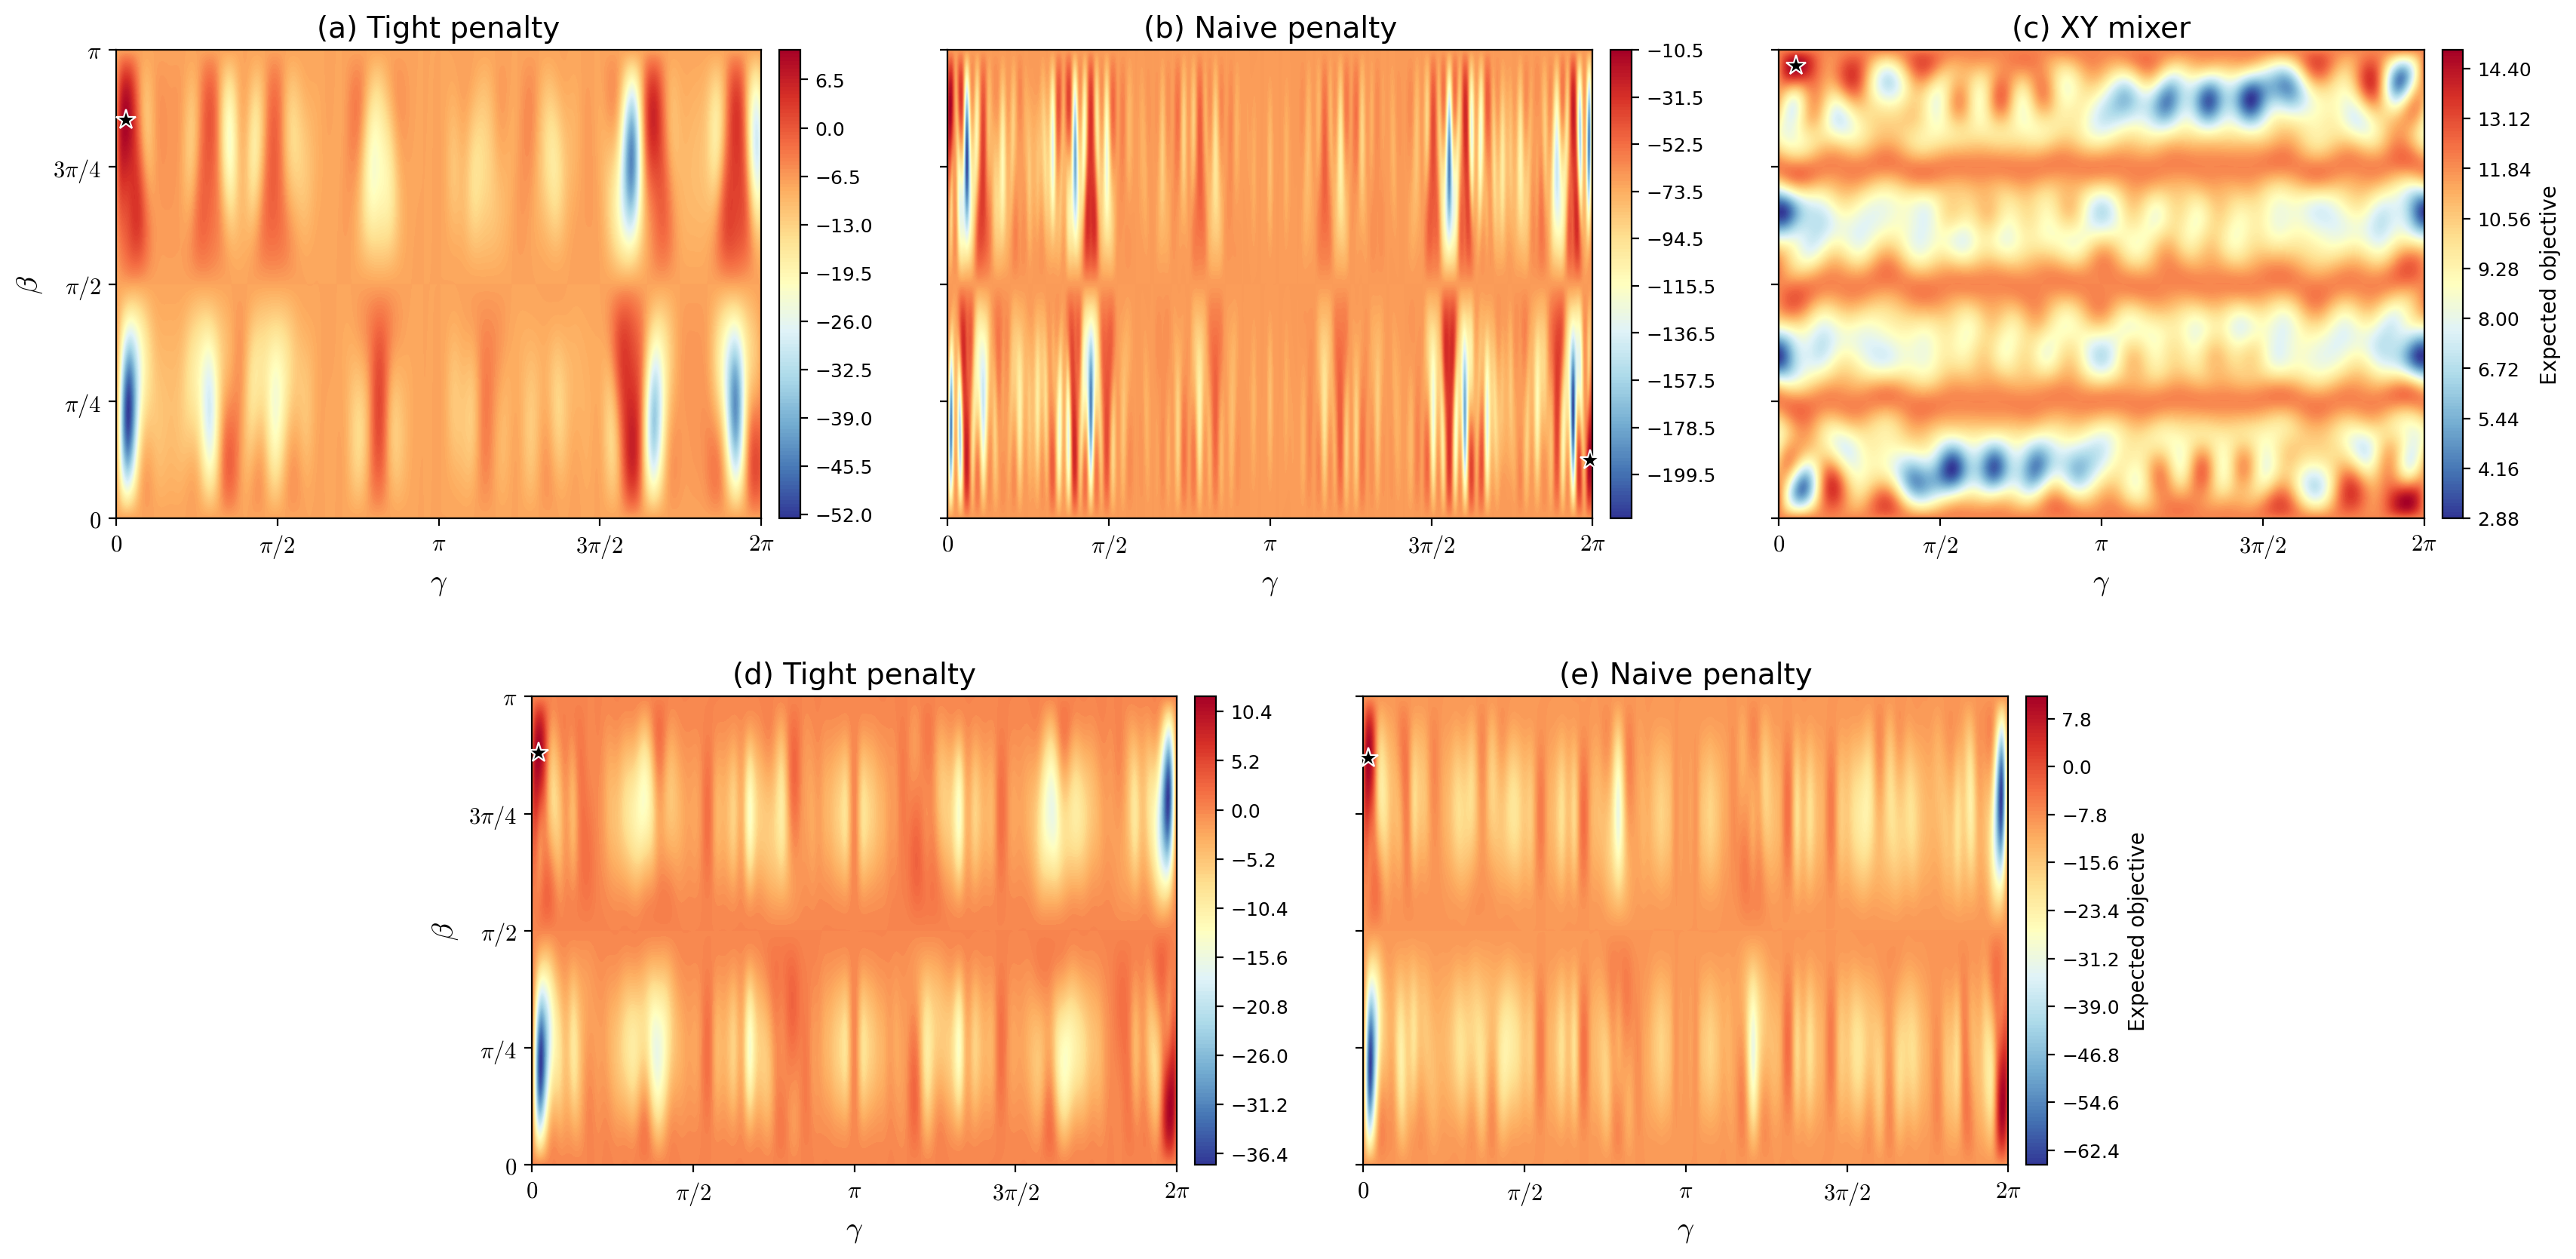

In [16]:
# ── QUBO and RQUBO landscapes (two rows: 3 QUBO panels, 2 centered RQUBO panels) ──
qubo_labels = ["QUBO tight", "QUBO naive", "QUBO (XY)"]
qubo_titles = ["(a) Tight penalty", "(b) Naive penalty", "(c) XY mixer"]
rqubo_labels = ["RQUBO tight", "RQUBO naive"]
rqubo_titles = ["(d) Tight penalty", "(e) Naive penalty"]
all_plot_labels = qubo_labels + rqubo_labels

GAMMA, BETA = np.meshgrid(gamma_vals, beta_vals)

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize=(17, 8.8))
gs = fig.add_gridspec(
    2, 6,
    wspace=0.55,
    hspace=0.38,
    left=0.065,
    right=0.98,
    top=0.93,
    bottom=0.09,
)
axes = (
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
)

for j, (ax, label, title) in enumerate(zip(axes, all_plot_labels, qubo_titles + rqubo_titles)):
    land = landscapes[label]
    cf = ax.contourf(GAMMA, BETA, land, levels=CONTOUR_LEVELS, cmap=CMAP)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3.2%", pad=0.12)
    cbar = fig.colorbar(cf, cax=cax)
    cbar.ax.tick_params(labelsize=9)
    if j in (2, 4):
        cbar.set_label("Expected objective", fontsize=10)

    gopt, bopt, _ = optima[label]
    ax.plot(
        gopt,
        bopt,
        marker="*",
        color="black",
        markersize=10,
        markeredgecolor="white",
        markeredgewidth=0.8,
        clip_on=False,
        zorder=5,
    )

    ax.set_xlabel(r"$\gamma$")
    ax.set_title(title)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_yticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    ax.set_yticklabels([r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
    ax.margins(x=0.03, y=0.03)

# Y-axis label only on left column of each row (avoids clash with neighbour panels).
axes[0].set_ylabel(r"$\beta$")
axes[3].set_ylabel(r"$\beta$")
for ax in (axes[1], axes[2], axes[4]):
    ax.tick_params(axis="y", labelleft=False)

combined_pdf = os.path.join(DATA_DIR, "cost_landscape_combined.pdf")
#fig.savefig(combined_pdf, bbox_inches="tight")
#print("Saved:", combined_pdf)
plt.show()


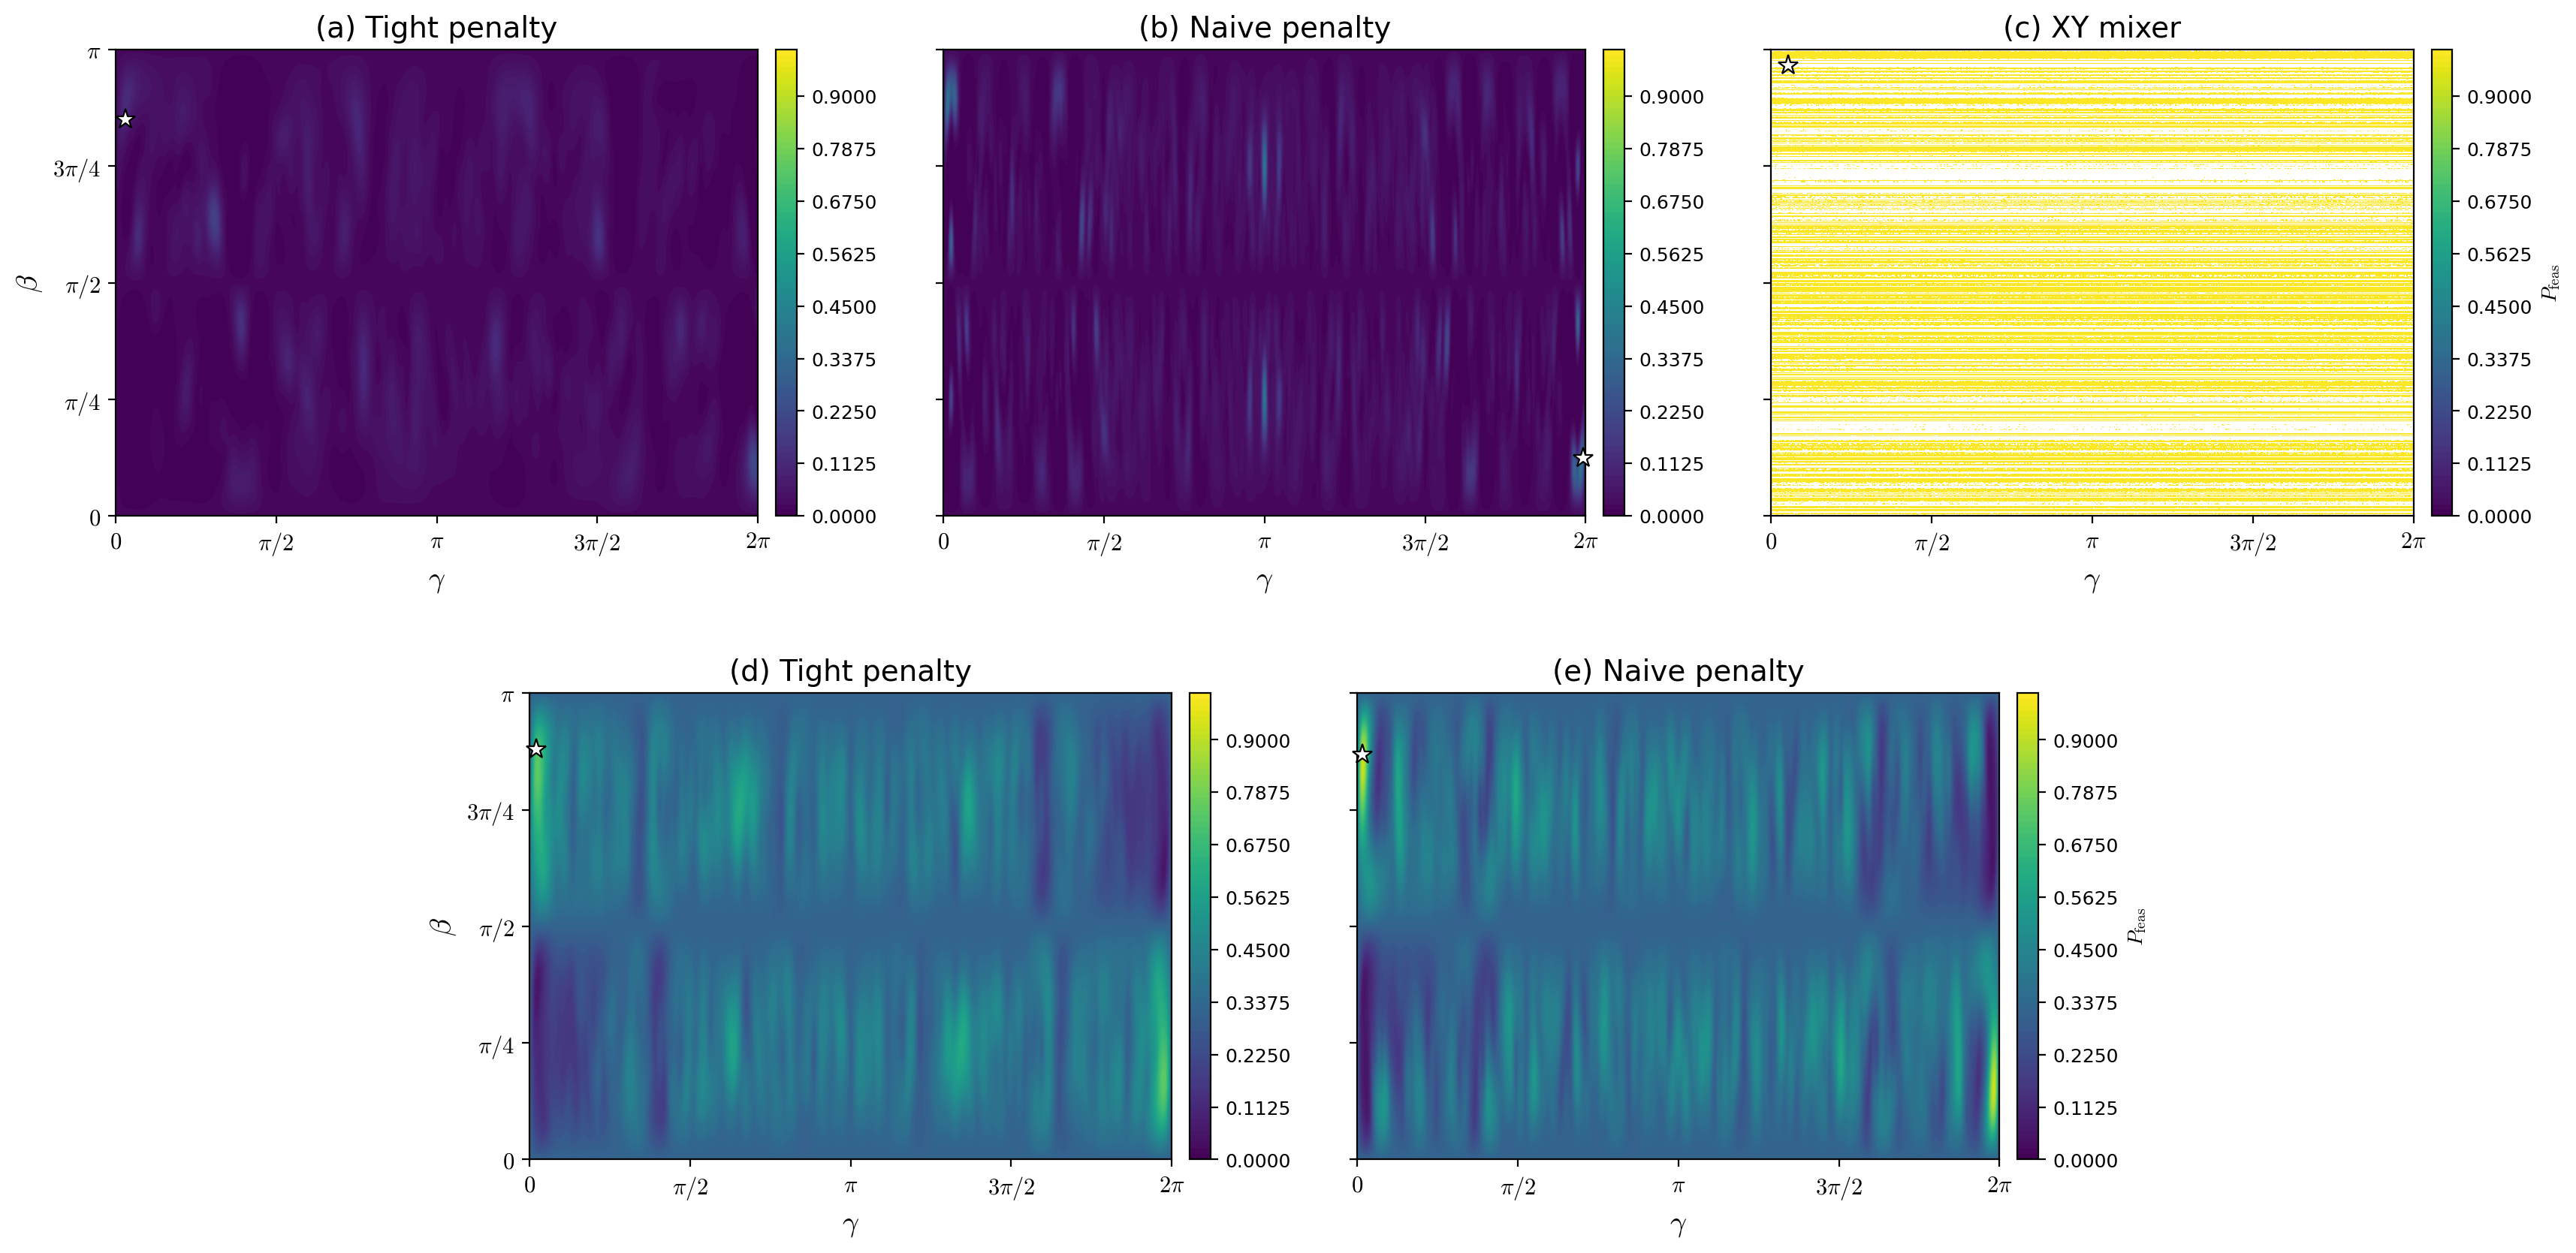

In [17]:
# ── Feasibility probability P_feas(γ, β) — same grid / panels as objective landscapes ──
# Requires *feas_landscapes* from the computation cell above.

if not feas_landscapes:
    raise RuntimeError("feas_landscapes is empty — run the landscape + feasibility cell first.")

GAMMA, BETA = np.meshgrid(gamma_vals, beta_vals)
FEAS_CMAP = "viridis"
FEAS_LEVELS = min(CONTOUR_LEVELS, 80)

qubo_labels = ["QUBO tight", "QUBO naive", "QUBO (XY)"]
qubo_titles = ["(a) Tight penalty", "(b) Naive penalty", "(c) XY mixer"]
rqubo_labels = ["RQUBO tight", "RQUBO naive"]
rqubo_titles = ["(d) Tight penalty", "(e) Naive penalty"]
all_plot_labels = qubo_labels + rqubo_labels

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize=(17, 8.8))
gs = fig.add_gridspec(
    2, 6,
    wspace=0.55,
    hspace=0.38,
    left=0.065,
    right=0.98,
    top=0.93,
    bottom=0.09,
)
axes = (
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
)

for j, (ax, label, title) in enumerate(zip(axes, all_plot_labels, qubo_titles + rqubo_titles)):
    land = feas_landscapes[label]
    cf = ax.contourf(
        GAMMA, BETA, land,
        levels=np.linspace(0.0, 1.0, FEAS_LEVELS + 1),
        cmap=FEAS_CMAP,
        vmin=0.0,
        vmax=1.0,
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3.2%", pad=0.12)
    cbar = fig.colorbar(cf, cax=cax)
    cbar.ax.tick_params(labelsize=9)
    if j in (2, 4):
        cbar.set_label(r"$P_{\mathrm{feas}}$", fontsize=10)

    gopt, bopt, _ = optima[label]
    ax.plot(
        gopt,
        bopt,
        marker="*",
        color="white",
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.8,
        clip_on=False,
        zorder=5,
    )

    ax.set_xlabel(r"$\gamma$")
    ax.set_title(title)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_yticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    ax.set_yticklabels([r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
    ax.margins(x=0.03, y=0.03)

axes[0].set_ylabel(r"$\beta$")
axes[3].set_ylabel(r"$\beta$")
for ax in (axes[1], axes[2], axes[4]):
    ax.tick_params(axis="y", labelleft=False)

feas_pdf = os.path.join(DATA_DIR, "cost_landscape_feasibility_combined.pdf")
# fig.savefig(feas_pdf, bbox_inches="tight")
# print("Saved:", os.path.abspath(feas_pdf))
plt.show()


Loaded CVaR landscapes from Data/cost_landscape_cvar_a0.25.pkl
CVaR QUBO tight      optimum at (γ=0.226, β=1.997)  value=15.6440
CVaR QUBO naive      optimum at (γ=6.239, β=0.340)  value=14.2858
CVaR RQUBO tight     optimum at (γ=6.164, β=0.277)  value=17.0000
CVaR RQUBO naive     optimum at (γ=6.201, β=0.267)  value=17.0000
CVaR QUBO (XY)       optimum at (γ=2.805, β=0.053)  value=17.0000


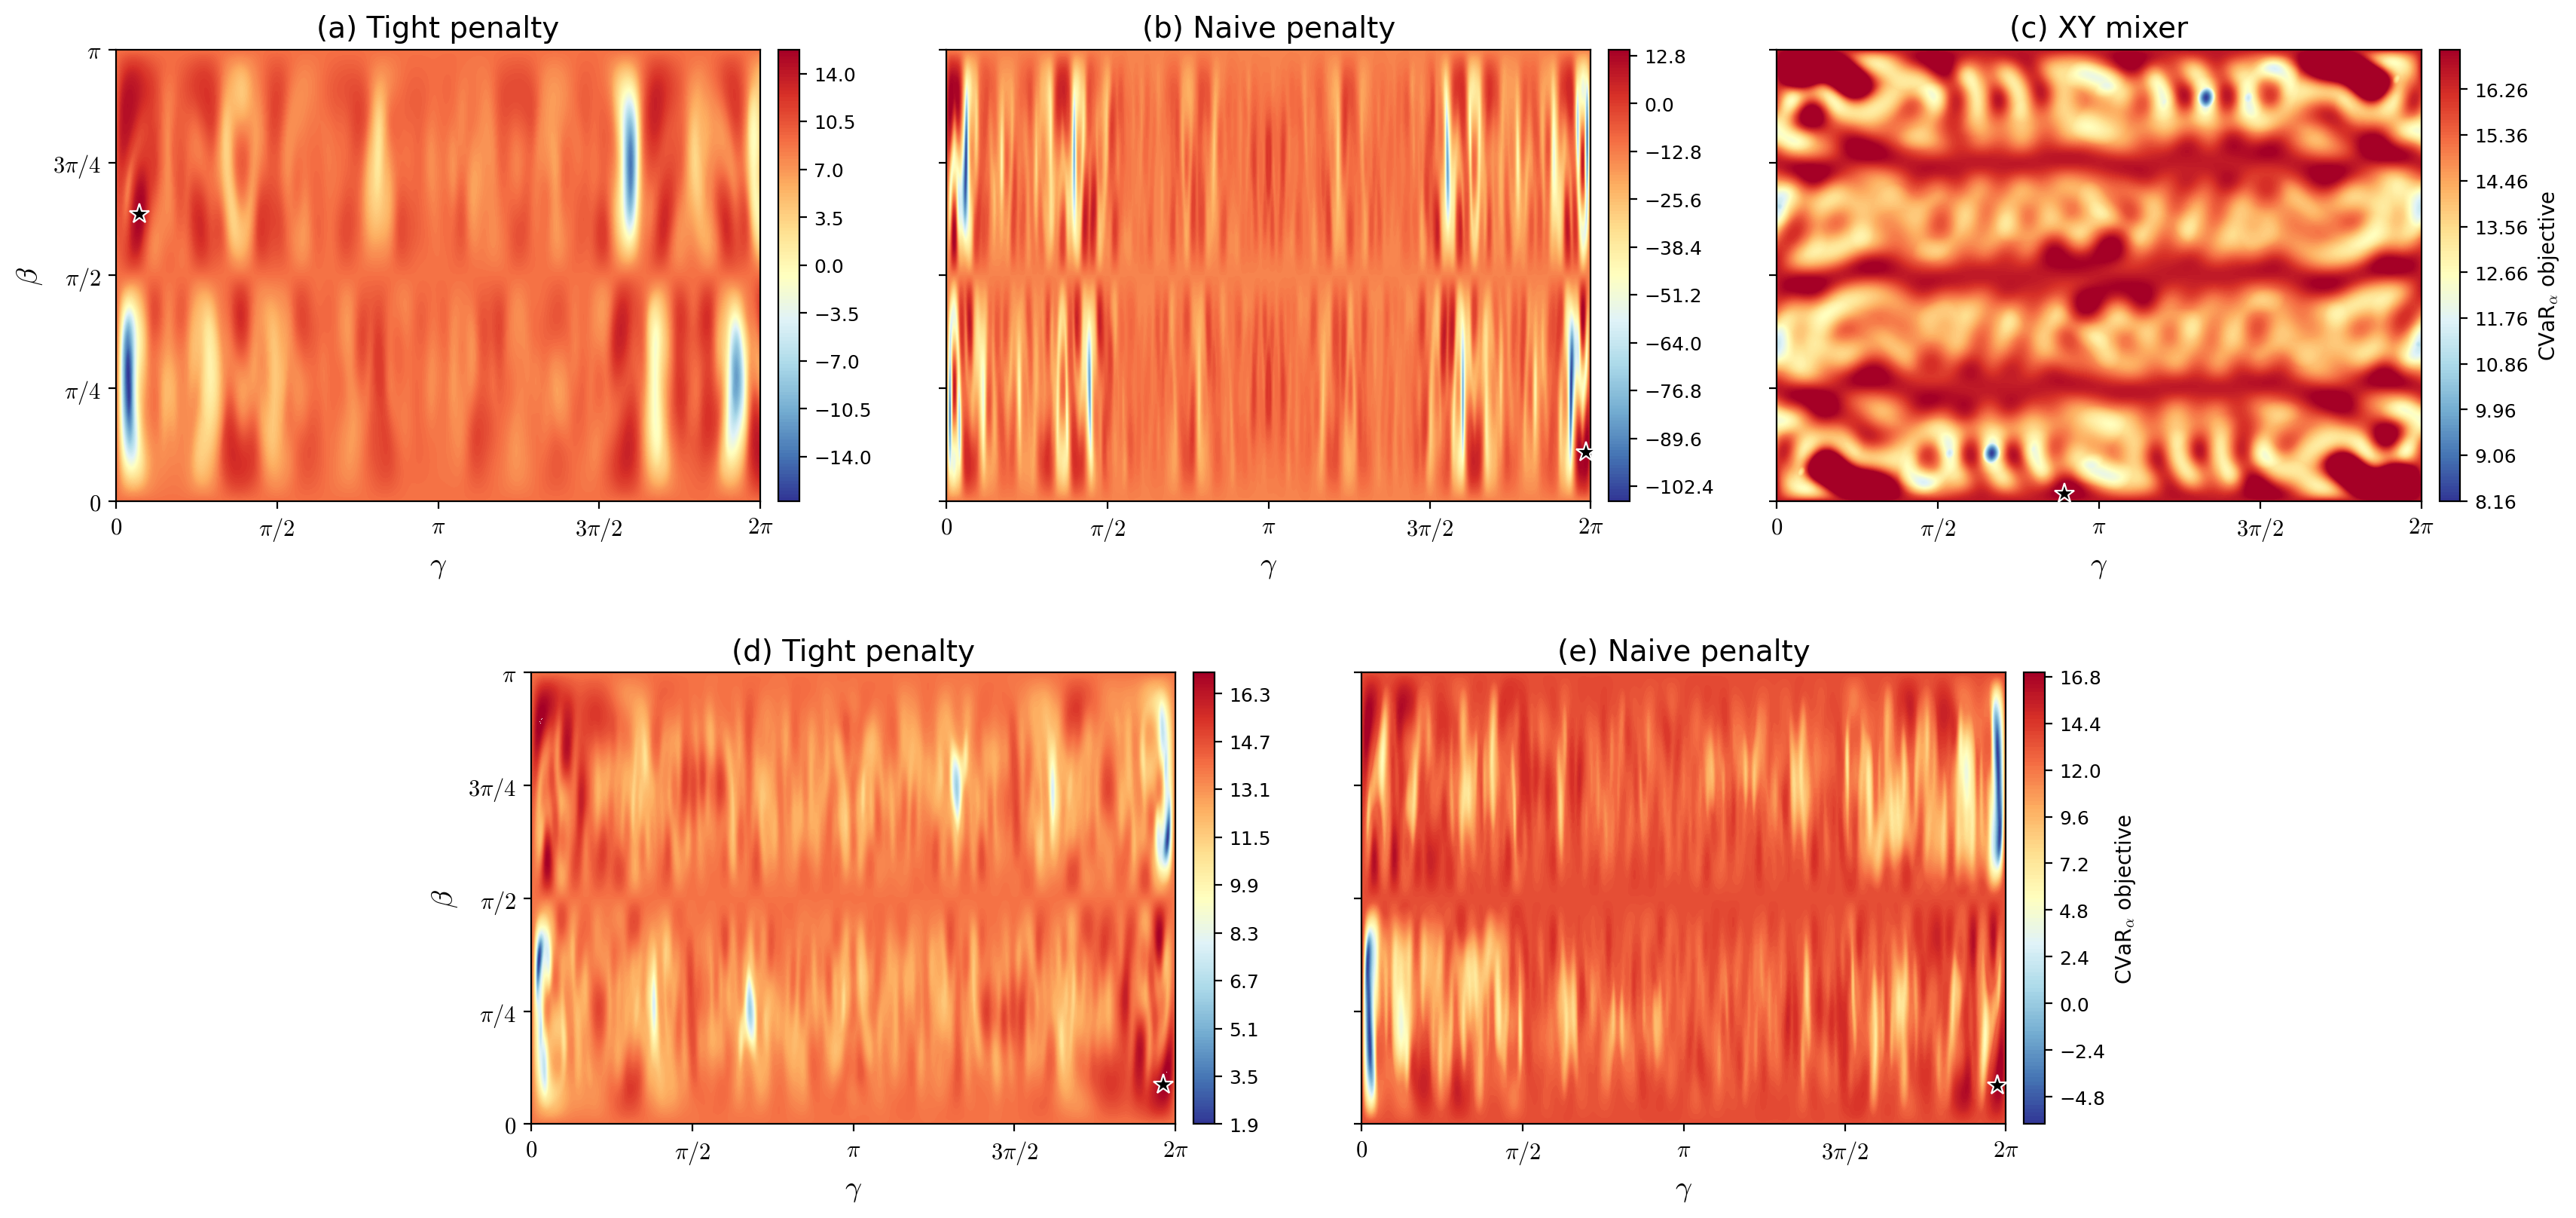

In [18]:
# ── CVaR objective landscapes (same grid as expectation; cache per α) ──
# CVaR here: average of the best α probability mass on the discrete outcome distribution (max objective).

CVAR_CACHE = os.path.join(DATA_DIR, f"cost_landscape_cvar_a{CVAR_ALPHA}.pkl")

_cc = None
if not FORCE_RECOMPUTE_CVAR and os.path.isfile(CVAR_CACHE):
    with open(CVAR_CACHE, "rb") as f:
        _cc = pickle.load(f)
if (
    not FORCE_RECOMPUTE_CVAR
    and _cc is not None
    and _cc.get("alpha") == CVAR_ALPHA
):
    cvar_landscapes = _cc["landscapes"]
    cvar_optima = _cc["optima"]
    print("Loaded CVaR landscapes from", CVAR_CACHE)
else:
    import time as _time

    cvar_landscapes = {}
    for label in ["QUBO tight", "QUBO naive", "RQUBO tight", "RQUBO naive"]:
        t0 = _time.time()
        cvar_landscapes[label] = compute_cvar_landscape(
            ising[label]["operator"],
            ising[label]["offset"],
            gamma_vals,
            beta_vals,
            CVAR_ALPHA,
        )
        print(f"CVaR {label:16s}  {_time.time() - t0:.1f}s")

    beta_param = Parameter("β")
    xy_mixer = create_ring_xy_mixer(num_nodes, K, beta_param)
    dicke_init = create_dicke_initial_state(num_nodes, K)

    t0 = _time.time()
    cvar_landscapes["QUBO (XY)"] = compute_cvar_landscape(
        ising["QUBO (XY)"]["operator"],
        ising["QUBO (XY)"]["offset"],
        gamma_vals,
        beta_vals,
        CVAR_ALPHA,
        mixer=xy_mixer,
        initial_state=dicke_init,
    )
    print(f"CVaR {'QUBO (XY)':16s}  {_time.time() - t0:.1f}s")

    cvar_optima = {}
    for label, land in cvar_landscapes.items():
        idx = np.unravel_index(np.argmax(land), land.shape)
        cvar_optima[label] = (gamma_vals[idx[1]], beta_vals[idx[0]], land[idx])

    with open(CVAR_CACHE, "wb") as f:
        pickle.dump(
            {"alpha": CVAR_ALPHA, "landscapes": cvar_landscapes, "optima": cvar_optima},
            f,
        )
    print("Saved:", CVAR_CACHE)

for label in cvar_landscapes:
    g, b, v = cvar_optima[label]
    print(f"CVaR {label:14s}  optimum at (γ={g:.3f}, β={b:.3f})  value={v:.4f}")

# --- same panel layout as the expectation figure ---
qubo_labels = ["QUBO tight", "QUBO naive", "QUBO (XY)"]
qubo_titles = ["(a) Tight penalty", "(b) Naive penalty", "(c) XY mixer"]
rqubo_labels = ["RQUBO tight", "RQUBO naive"]
rqubo_titles = ["(d) Tight penalty", "(e) Naive penalty"]
all_plot_labels = qubo_labels + rqubo_labels

GAMMA, BETA = np.meshgrid(gamma_vals, beta_vals)
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize=(17, 8.8))
gs = fig.add_gridspec(
    2, 6,
    wspace=0.55,
    hspace=0.38,
    left=0.065,
    right=0.98,
    top=0.90,
    bottom=0.09,
)
axes = (
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
)

for j, (ax, label, title) in enumerate(zip(axes, all_plot_labels, qubo_titles + rqubo_titles)):
    land = cvar_landscapes[label]
    cf = ax.contourf(GAMMA, BETA, land, levels=CONTOUR_LEVELS, cmap=CMAP)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3.2%", pad=0.12)
    cbar = fig.colorbar(cf, cax=cax)
    cbar.ax.tick_params(labelsize=9)
    if j in (2, 4):
        cbar.set_label(r"CVaR$_\alpha$ objective", fontsize=10)

    gopt, bopt, _ = cvar_optima[label]
    ax.plot(
        gopt,
        bopt,
        marker="*",
        color="black",
        markersize=10,
        markeredgecolor="white",
        markeredgewidth=0.8,
        clip_on=False,
        zorder=5,
    )

    ax.set_xlabel(r"$\gamma$")
    ax.set_title(title)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    ax.set_yticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    ax.set_yticklabels([r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
    ax.margins(x=0.03, y=0.03)

axes[0].set_ylabel(r"$\beta$")
axes[3].set_ylabel(r"$\beta$")
for ax in (axes[1], axes[2], axes[4]):
    ax.tick_params(axis="y", labelleft=False)

# fig.suptitle(
#     rf"CVaR objective ($\alpha={CVAR_ALPHA}$: best $\alpha$ mass; discrete outcomes)",
#     fontsize=12,
#     y=0.98,
# )

combined_cvar_pdf = os.path.join(DATA_DIR, f"cost_landscape_cvar_a{CVAR_ALPHA}.pdf")
#fig.savefig(combined_cvar_pdf, bbox_inches="tight")
#print("Saved:", combined_cvar_pdf)
plt.show()

Saved: Data/landscape_variance.pdf


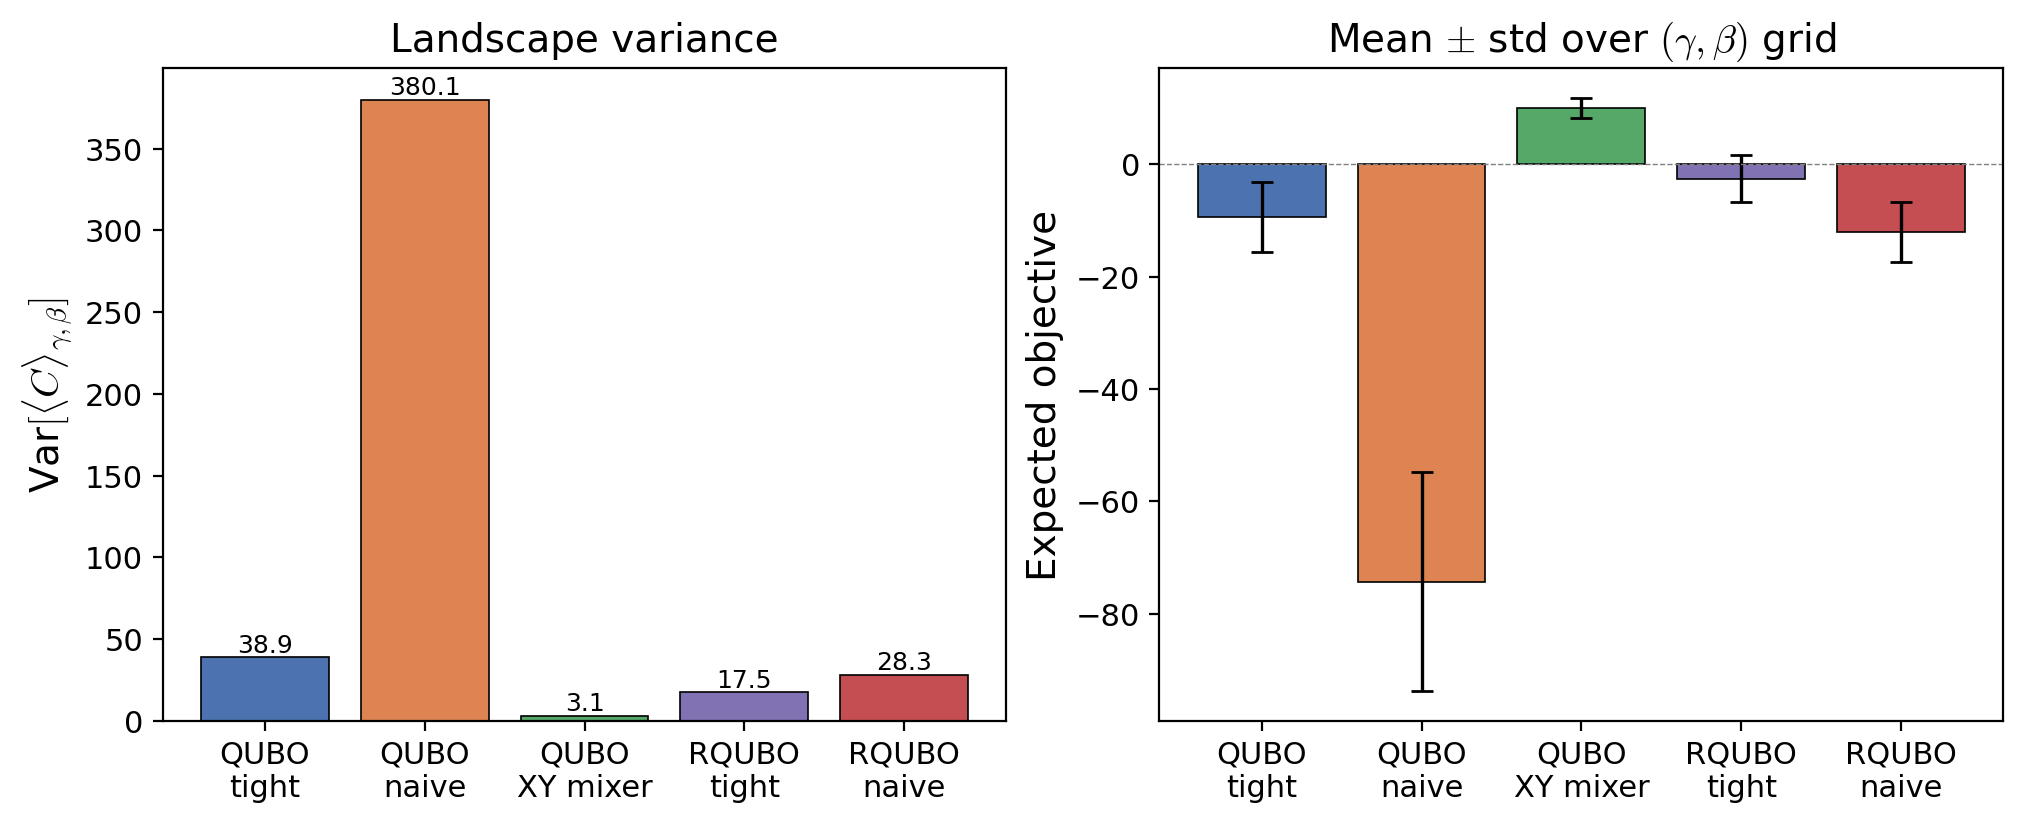

In [19]:
# ── Figure 3: Variance of expected objective across (γ, β) grid ──
all_labels = ["QUBO tight", "QUBO naive", "QUBO (XY)", "RQUBO tight", "RQUBO naive"]
display_names = ["QUBO\ntight", "QUBO\nnaive", "QUBO\nXY mixer", "RQUBO\ntight", "RQUBO\nnaive"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#8172B3", "#C44E52"]

means = [np.mean(landscapes[l]) for l in all_labels]
stds  = [np.std(landscapes[l])  for l in all_labels]
var   = [np.var(landscapes[l])  for l in all_labels]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# Left: variance bar chart
bars = axes[0].bar(display_names, var, color=colors, edgecolor="black", linewidth=0.6)
axes[0].set_ylabel("Var$[\\langle C \\rangle_{\\gamma,\\beta}]$")
axes[0].set_title("Landscape variance")
for bar, v in zip(bars, var):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{v:.1f}", ha="center", va="bottom", fontsize=9)

# Right: mean ± std
x = np.arange(len(all_labels))
axes[1].bar(x, means, yerr=stds, color=colors, edgecolor="black", linewidth=0.6,
            capsize=4, error_kw={"linewidth": 1.2})
axes[1].set_xticks(x)
axes[1].set_xticklabels(display_names)
axes[1].set_ylabel("Expected objective")
axes[1].set_title(r"Mean $\pm$ std over $(\gamma, \beta)$ grid")
axes[1].axhline(0, color="grey", linewidth=0.5, linestyle="--")

var_pdf = os.path.join(DATA_DIR, "landscape_variance.pdf")
fig.savefig(var_pdf, bbox_inches="tight")
print("Saved:", var_pdf)
plt.show()